In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Bidirectional, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr


2024-07-09 16:40:31.174619: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-09 16:40:31.226784: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-09 16:40:31.227932: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-09 16:40:34.724390: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# Subfunctions

In [2]:
# def load_data():
#     X_train = np.load('data/processed/X_train.npy')
#     y_train = np.load('data/processed/y_train.npy')
#     X_val = np.load('data/processed/X_val.npy')
#     y_val = np.load('data/processed/y_val.npy')
#     return X_train, y_train, X_val, y_val

# def build_model(input_shape):
#     model = keras.Sequential([
#         keras.layers.Dense(32, activation='relu', input_shape=(input_shape,)),
#         keras.layers.Dense(16, activation='relu'),
#         keras.layers.Dense(1)
#     ])
#     model.compile(optimizer='adam', loss='mean_squared_error')
#     return model

# def train_model(X_train, y_train, X_val, y_val):
#     model = build_model(X_train.shape[1])
#     model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))
#     model.save('models/air_quality_model.h5')

# def main():
#     X_train, y_train, X_val, y_val = load_data()
#     train_model(X_train, y_train, X_val, y_val)

# Function to create multivariate sequences
def create_sequences(data, data_indices, seq_length, pred_length):
    X, y, X_indices, y_indices = [], [], [], []
    for i in range(len(data) - seq_length - pred_length + 1):
        X.append(data[i:(i + seq_length), :])
        y.append(data[(i + seq_length):(i + seq_length + pred_length), -1])  # Assuming the target is the last variable
        X_indices.append(data_indices[i:(i + seq_length)])
        y_indices.append(data_indices[(i + seq_length):(i + seq_length + pred_length)])
    return np.array(X), np.array(y), X_indices, y_indices


### Functions for training models

In [3]:
# Training and evaluation function
def train_and_evaluate(models,
                       X_train, y_train, X_test, y_test,
                       epochs,
                       batch_size,
                       patience,
                       forecast_hours,
                       key):
    history = {}
    results = {}
    early_stopping = EarlyStopping(monitor='val_loss', patience = patience, restore_best_weights=True)  # Configure early stopping

    for name, model in models.items():
        model.compile(optimizer='adam', loss='mse', metrics=['mse'])  # Add MSE as a metric

        # Add a check to ensure input and output dimensions match
        if y_train.shape[1] != model.layers[-1].output_shape[1]:
            raise ValueError(f"Output dimension mismatch for model {name}. "
                             f"Expected: {y_train.shape[1]}, Got: {model.layers[-1].output_shape[1]}")

        history[name] = model.fit(
            X_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_test, y_test),
            callbacks=[early_stopping],  # Add the early stopping callback
            verbose=0)
        results[name] = model.evaluate(X_test, y_test, verbose=0)
        # print(f'{name} Test Loss: {results[name][0]}, Test MSE: {results[name][1]}')  # Print both loss and MSE
        print(f'Test MSE: {results[name][1]}')  # Print both loss and MSE
        plot_training_history(history[name], name, forecast_hours, key)  # Plot training history for each model
    return history, results

## Ploting historical training and validating
def plot_training_history(history, name, forecast_hours, key):
    plt.figure(figsize=(12, 3))
    # plt.plot(history.history['loss'], label='Train Loss')
    # plt.plot(history.history['val_loss'], label='Val Loss')
    plt.plot(history.history['mse'], label='Train MSE')  # Plot MSE
    plt.plot(history.history['val_mse'], label='Val MSE')  # Plot MSE
    plt.title(f'Training vs. Validation Metrics for {name} at {forecast_hours}-hour forecast [{key}]')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
# Function to create models
def create_models(input_shape, output_length):
    models = {}

    # 1D CNN
    cnn_model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(output_length)
    ])
    models['1D CNN'] = cnn_model

    # LSTM
    lstm_model = Sequential([
        LSTM(128, activation='tanh', return_sequences= True, input_shape=input_shape),
        LSTM(128, activation='tanh'),
        Dense(64, activation='relu'),
        Dense(output_length)
    ])
    models['LSTM'] = lstm_model

    # GRU
    gru_model = Sequential([
        GRU(128, activation='tanh', input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(output_length)
    ])
    models['GRU'] = gru_model

    # BiLSTM
    bilstm_model = Sequential([
        Bidirectional(LSTM(128, activation='tanh'), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(output_length)
    ])
    models['BiLSTM'] = bilstm_model

    # CNN-LSTM
    cnn_lstm_model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        # MaxPooling1D(pool_size=2),
        # Reshape((input_shape)),
        LSTM(100, activation='tanh'),
        Dense(100, activation='relu'),
        Dense(output_length)
    ])
    # print(cnn_lstm_model.summary())
    models['CNN-LSTM'] = cnn_lstm_model

    # ANN
    ann_model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(100, activation='relu'),
        Dense(100, activation='relu'),
        Dense(output_length)
    ])
    models['ANN'] = ann_model

    return models

### Forecasting functions

In [5]:
# Forecasting function
def forecast(models, X, pred_length):
    forecasts = {}
    for name, model in models.items():
        forecast = model.predict(X[-1].reshape(1, seq_length, X.shape[2]), verbose = 0)
        # print(np.array(forecast).shape)
        # forecasts[name] = scaler.inverse_transform(forecast).flatten()
        # forecasts[name] = scaler_target.inverse_transform(forecast).flatten()

        forecasts[name] = forecast
    return forecasts


def plot_forecasts(data, forecasts, pred_length, title):
    print(data)
    print(forecasts)
    plt.figure(figsize=(15, 4))
    plt.plot(data.index[-(seq_length+pred_length):], data.values[-(seq_length+pred_length):], label='Real_OBS', linewidth = 3)
    for name, forecast in forecasts.items():
        print(data.index[-forecast.shape[1]:])
        forecast = forecast.flatten()
        print("forecast", forecast)
        index = data.index[-forecast.shape[0]:]
        print("index", index)
        plt.plot(index, forecast,  markersize=10,  label=f'{name} Forecast')

    # plt.plot(data.index[-len(forecasts['LSTM']):], forecasts['LSTM'], marker='o', markersize=10,  label=f'Forecast', color = 'red')
    plt.xticks(rotation=90)
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Magnitude')
    plt.legend()
    plt.show()

### Evaluation functions

In [6]:
def calculate_statistics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    pearson_r, _ = pearsonr(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, pearson_r, r2

def evaluate_forecasts(forecasts, y_true):
    statistics = {}
    for name, forecast in forecasts.items():
        rmse, mae, pearson_r, r2 = np.round(calculate_statistics(y_true, forecast[0]),6)
        statistics[name] = {
            'RMSE': rmse,
            'MAE': mae,
            'Pearson\'s r': pearson_r,
            'R²': r2
        }
        # print(f"{name} - RMSE: {rmse}, MAE: {mae}, Pearson's r: {pearson_r}, R²: {r2}")
    return statistics

# Convert statistics to DataFrame and display
def statistics_to_dataframe(statistics, pred_length):
    df = pd.DataFrame(statistics).T
    df.index.name = 'Model'
    df.columns = ['RMSE', 'MAE', 'Pearson\'s r', 'R²']
    df['Pred. Length'] = pred_length
    return df

## Data preparation

#### Normalized Lidcombe station data

In [7]:
data = {}
data['station'] = pd.read_csv("/home/htle/Downloads/nowcasting_framework/data/processed/colocation/Lidcombe/AQMS/20210301_20231231/aqms_1141_corrected_normalized.csv",index_col="datetime_utc", parse_dates=True)
data['station'].index = pd.to_datetime(data['station'].index,format="%d/%m%Y %H:%M")
data['station'].index = data['station'].index.strftime("%Y-%m-%d %H:%M:%S")
data['station'].head()


,HUMID,TEMP,PM2.5,PM10,timestamp
datetime_utc,,,,,
2020-11-01 01:00:00,0.974077,0.344087,0.004297,0.007724,1604152800
2020-11-01 02:00:00,0.980475,0.338301,0.005660,0.006480,1604156400
2020-11-01 03:00:00,0.985053,0.333571,0.003938,0.011721,1604160000
2020-11-01 04:00:00,0.984935,0.335454,0.004868,0.013599,1604163600
2020-11-01 05:00:00,0.979672,0.340000,0.006654,0.015819,1604167200


#### Normalized DSI data at Lidcombe

In [8]:
data['dsi'] = pd.read_csv("/home/htle/Downloads/nowcasting_framework/data/processed/colocation/Lidcombe/DSI/20210301_20221231/normalized/dsi_Lidcombe_20210301-20221231_hourly.csv",index_col="datetime_utc", parse_dates=True)
data['dsi'].head()

,HUMID,TEMP,PM2.5,PM10
datetime_utc,,,,
2021-02-28 13:00:00,0.419984,0.561194,0.002545,0.002387
2021-02-28 14:00:00,0.459766,0.586682,0.008009,0.009000
2021-02-28 15:00:00,0.459766,0.586682,0.007481,0.008438
2021-02-28 16:00:00,0.459766,0.586682,0.007078,0.007866
2021-02-28 17:00:00,0.459766,0.586682,0.007233,0.007990


#### Normalized sensor data at Lidcombe

In [9]:
sensor_names = ['91355','91721','92367']
for sensor in sensor_names:
    data[sensor] = pd.read_csv(f"/home/htle/Downloads/nowcasting_framework/data/processed/colocation/Lidcombe/DSI/20210301_20221231/normalized/{sensor}_corrected.csv",index_col="datetime_utc", parse_dates=True)

for sensor in sensor_names:
    data[sensor] = data[sensor].resample('1H').mean()
    print(data[sensor].head())


                        HUMID      TEMP     PM2.5      PM10    time_stamp
datetime_utc                                                             
2020-11-20 17:00:00  0.215209  0.395408  0.004818  0.001747  1.605895e+09
2020-11-20 18:00:00  0.223361  0.387600  0.004710  0.001336  1.605897e+09
2020-11-20 19:00:00  0.221405  0.436051  0.174467  0.297250  1.605900e+09
2020-11-20 20:00:00  0.000000  0.025488  0.001275  0.000000  1.605904e+09
2020-11-20 21:00:00  0.000000  0.025488  0.001275  0.000000  1.605908e+09
                        HUMID      TEMP     PM2.5      PM10    time_stamp
datetime_utc                                                             
2020-11-23 18:00:00  0.195645  0.417681  0.006154  0.005684  1.606157e+09
2020-11-23 19:00:00  0.201188  0.462572  0.338041  0.466680  1.606160e+09
2020-11-23 20:00:00  0.068040  0.171450  0.032645  0.051737  1.606163e+09
2020-11-23 21:00:00  0.000000  0.025488  0.001275  0.000000  1.606167e+09
2020-11-23 22:00:00  0.000000  0.02548

In [10]:
print(data['station'])

                        HUMID      TEMP     PM2.5      PM10   timestamp
datetime_utc                                                           
2020-11-01 01:00:00  0.974077  0.344087  0.004297  0.007724  1604152800
2020-11-01 02:00:00  0.980475  0.338301  0.005660  0.006480  1604156400
2020-11-01 03:00:00  0.985053  0.333571  0.003938  0.011721  1604160000
2020-11-01 04:00:00  0.984935  0.335454  0.004868  0.013599  1604163600
2020-11-01 05:00:00  0.979672  0.340000  0.006654  0.015819  1604167200
...                       ...       ...       ...       ...         ...
2023-05-31 20:00:00  0.657289  0.389575  0.013595  0.042416  1685527200
2023-05-31 21:00:00  0.686078  0.372675  0.014721  0.041205  1685530800
2023-05-31 22:00:00  0.730049  0.351917  0.014849  0.045545  1685534400
2023-05-31 23:00:00  0.748763  0.341837  0.015307  0.044980  1685538000
2023-06-01 00:00:00  0.767447  0.327003  0.014844  0.039325  1685541600

[22608 rows x 5 columns]


Synchronize time

In [11]:
# Extract the desired time range
# start_date = "2021-03-01 00:00"

# start_date = "2022-06-28 07:00:00"
# end_date = "2022-06-28 19:00:00"

start_date = "2022-11-05 01:00:00"
end_date = "2022-11-06 07:00:00"

# start_date = "2022-06-27 19:00:00"
# end_date = "2022-06-28 19:00:00"

time_range = pd.date_range(start=start_date, end=end_date, freq='H')

# Reindex and slice the data
data['station'] = data['station'].loc[start_date:end_date]
data['dsi'] = data['dsi'].loc[start_date:end_date]

for sensor in sensor_names:
    data[sensor] = data[sensor].loc[start_date:end_date]


In [12]:
# print(data.keys())
# for key, dt in data.items():
#   print('--------'*3 + f' Data of {key} ' + '-------'*3)
#   print(dt.describe())
#   print(f'--------------------------'*3)

In [13]:
training_var = 'PM2.5'
data_main = {key: dt[training_var] for key,dt in data.items()}
for key, dt in data.items():
  data_main[key] = dt[training_var]

for key, dt in data_main.items():
  print('--------'*3 + f' Data of {key} ' + '-------'*3)
  print(dt.describe())
  print(f'--------------------------'*3)

------------------------ Data of station ---------------------
count    31.000000
mean      0.005769
std       0.003027
min       0.001284
25%       0.003307
50%       0.005568
75%       0.007677
max       0.014116
Name: PM2.5, dtype: float64
------------------------------------------------------------------------------
------------------------ Data of dsi ---------------------
count    31.000000
mean      0.009460
std       0.013027
min       0.000931
25%       0.001350
50%       0.002080
75%       0.012681
max       0.049699
Name: PM2.5, dtype: float64
------------------------------------------------------------------------------
------------------------ Data of 91355 ---------------------
count    31.000000
mean      0.005987
std       0.005918
min       0.001929
25%       0.002673
50%       0.003465
75%       0.005479
max       0.027621
Name: PM2.5, dtype: float64
------------------------------------------------------------------------------
------------------------ Data of 91721 -

In [14]:
def create_sequences_df(data, data_indices, seq_length, pred_length):
    """
    Creates sequences of data for time series forecasting.

    Args:
        data: Pandas DataFrame containing time series data.
        data_indices: Pandas DateTimeIndex corresponding to the data.
        seq_length: Length of the input sequence.
        pred_length: Length of the output prediction.

    Returns:
        Tuple of lists: (X, y, X_indices, y_indices)
            X: List of input sequences.
            y: List of output targets.
            X_indices: List of indices corresponding to the input sequences.
            y_indices: List of indices corresponding to the output targets.
    """
    X, y, X_indices, y_indices = [], [], [], []
    for i in range(len(data) - seq_length - pred_length + 1):
        # Extract input sequence and target values using iloc for integer-based indexing
        X.append(data.iloc[i:(i + seq_length), :].values)  # Convert to NumPy array
        y.append(data.iloc[(i + seq_length):(i + seq_length + pred_length), -1].values)  # Assuming target is last column
        X_indices.append(data_indices[i:(i + seq_length)])
        y_indices.append(data_indices[(i + seq_length):(i + seq_length + pred_length)])
    return X, y, X_indices, y_indices

In [15]:
def create_sequences_ser(data, data_indices, seq_length, pred_length):
    """
    Creates sequences of data for time series forecasting.

    Args:
        data: Pandas DataFrame containing time series data.
        data_indices: Pandas DateTimeIndex corresponding to the data.
        seq_length: Length of the input sequence.
        pred_length: Length of the output prediction.

    Returns:
        Tuple of lists: (X, y, X_indices, y_indices)
            X: List of input sequences.
            y: List of output targets.
            X_indices: List of indices corresponding to the input sequences.
            y_indices: List of indices corresponding to the output targets.
    """
    X, y, X_indices, y_indices = [], [], [], []
    for i in range(len(data) - seq_length - pred_length + 1):
        # Extract input sequence and target values using iloc for integer-based indexing
        X.append(data.iloc[i:(i + seq_length)].values.reshape(-1, 1))  # Remove the extra ':' for Series slicing
        y.append(data.iloc[(i + seq_length):(i + seq_length + pred_length)].values)  # Assuming target is last column
        X_indices.append(data_indices[i:(i + seq_length)])
        y_indices.append(data_indices[(i + seq_length):(i + seq_length + pred_length)])
    return np.array(X), np.array(y), X_indices, y_indices



In [16]:
data_main.keys()

dict_keys(['station', 'dsi', '91355', '91721', '92367'])

In [17]:
# @title
# Parameters for input length and output forecast lengths
seq_length = 12                 ## Number of historical input values
pred_lengths = [3, 6]            ## Number of future out values

# ## Scale the data
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(df)
# scaler_target = StandardScaler()
# target_scaled = scaler_target.fit_transform(df.values[:,-1].reshape(-1,1))

# Create sequences for different prediction lengths
X = dict()
y = dict()
X_indices = dict()
y_indices = dict()

for key, value in data_main.items():
    for i in pred_lengths:
        X[f"{i}_{key}"], y[f"{i}_{key}"], X_indices[f"{i}_{key}"], y_indices[f"{i}_{key}"] = create_sequences_ser(value, value.index, seq_length, i)


In [18]:
from collections import OrderedDict

### Re arrange the data following the order of forecast
X = OrderedDict(sorted(X.items()))
y = OrderedDict(sorted(y.items()))
X_indices = OrderedDict(sorted(X_indices.items()))
y_indices = OrderedDict(sorted(y_indices.items()))

print(X.keys())
print(y.keys())
print(X_indices.keys())
print(y_indices.keys())

odict_keys(['3_91355', '3_91721', '3_92367', '3_dsi', '3_station', '6_91355', '6_91721', '6_92367', '6_dsi', '6_station'])
odict_keys(['3_91355', '3_91721', '3_92367', '3_dsi', '3_station', '6_91355', '6_91721', '6_92367', '6_dsi', '6_station'])
odict_keys(['3_91355', '3_91721', '3_92367', '3_dsi', '3_station', '6_91355', '6_91721', '6_92367', '6_dsi', '6_station'])
odict_keys(['3_91355', '3_91721', '3_92367', '3_dsi', '3_station', '6_91355', '6_91721', '6_92367', '6_dsi', '6_station'])


## Training models

In [19]:
import tensorflow as tf
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


2.13.1
Num GPUs Available:  0


2024-07-09 16:41:02.878008: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-09 16:41:02.878630: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [20]:
!nvidia-smi

Tue Jul  9 16:41:03 2024       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Quadro RTX 6000     Off  | 00000000:01:00.0 Off |                  Off |
| 33%   29C    P8    10W / 260W |     48MiB / 24576MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [1]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


2024-07-09 16:59:24.674475: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-09 16:59:24.709796: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-09 16:59:24.710467: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-09 16:59:26.667985: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Num GPUs Available:  0


2024-07-09 16:59:29.532976: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-07-09 16:59:29.533380: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Test MSE: 1.5559921848762315e-06


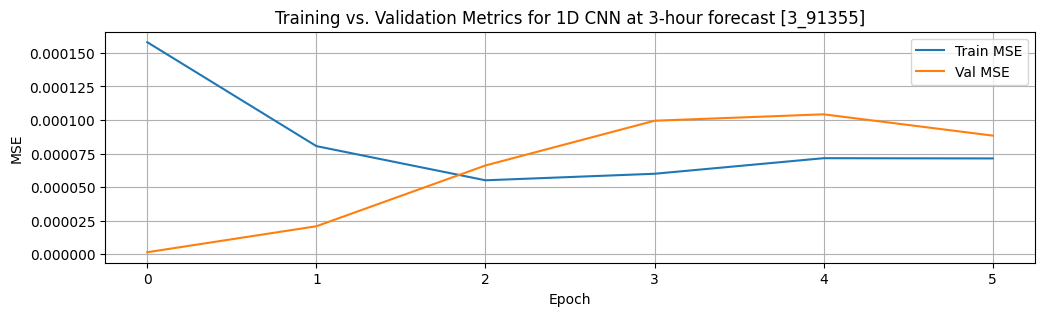

Test MSE: 8.092343705357052e-06


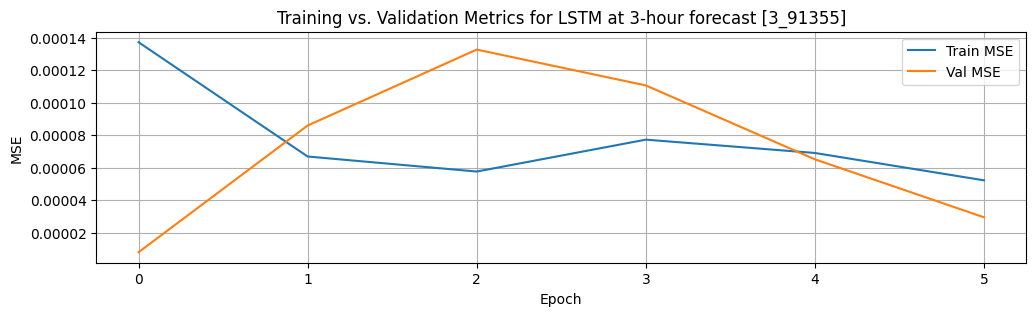

Test MSE: 3.844083948933985e-06


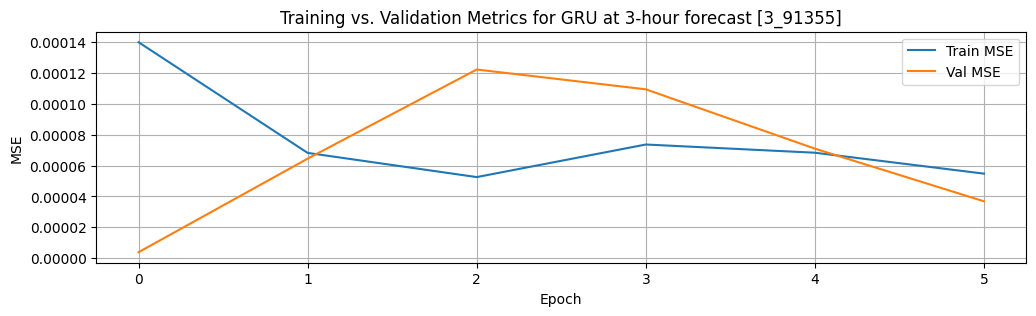

Test MSE: 1.1918169548152946e-05


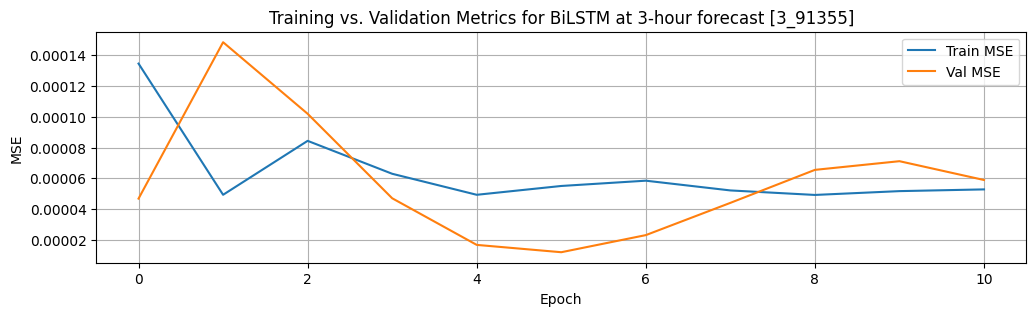

Test MSE: 1.5217150576063432e-05


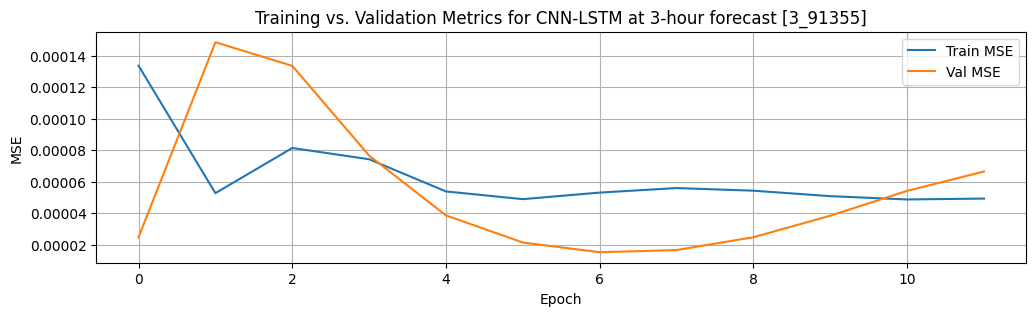

Test MSE: 4.792643721884815e-06


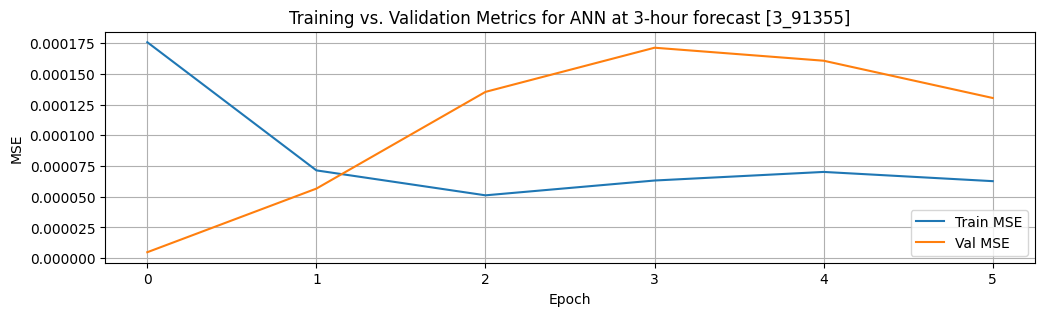

Test MSE: 2.2782065570936538e-05


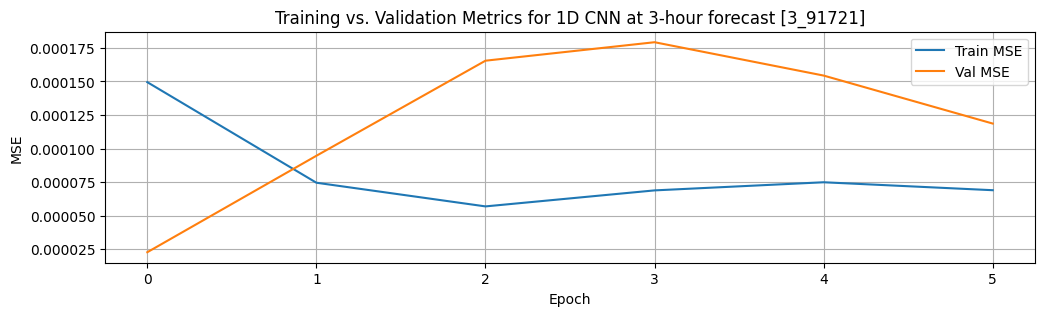

Test MSE: 4.702220394392498e-06


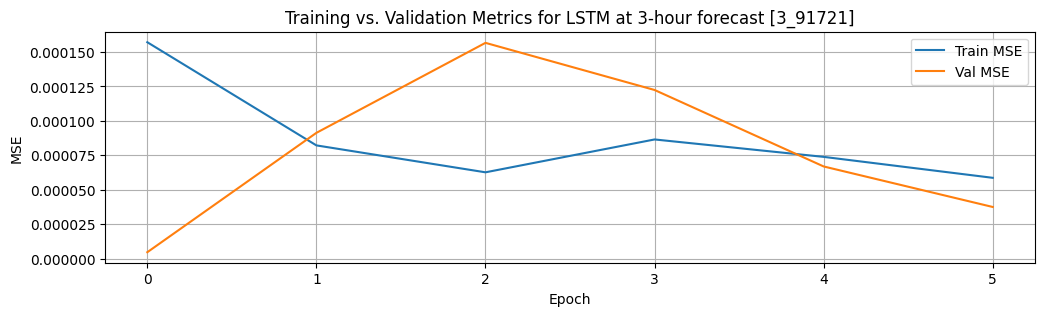

KeyboardInterrupt: 

In [22]:
# Split data into train and test sets
split_ratio = 0.9
# pred_lengths

# train_size = int(len(X[forecast_length]) * split_ratio)

X_train = dict()
y_train = dict()
X_test = dict()
y_test = dict()

for key in X.keys():
    train_size = int(len(X[key]) * split_ratio)
    X_train[key], X_test[key] = X[key][:train_size], X[key][train_size:]
    y_train[key], y_test[key] = y[key][:train_size], y[key][train_size:]

# key = 'dsi_6'
# print(f"Shape of X_train[{key}]: {X_train[key].shape}")
# print(f"Shape of y_train[{key}]: {y_train[key].shape}")
# print(f"Shape of X_test[{key}]: {X_test[key].shape}")
# print(f"Shape of y_test[{key}]: {y_test[key].shape}")

# # Print shapes for debugging
# for key in X_train.keys():
#     print(f"Shape of X_train[{key}]: {X_train[key].shape}")
#     print(f"Shape of y_train[{key}]: {y_train[key].shape}")
#     print(f"Shape of X_test[{key}]: {X_test[key].shape}")
#     print(f"Shape of y_test[{key}]: {y_test[key].shape}")

# X_train[forecast_length], X_test[forecast_length] = X[forecast_length][:train_size], X[forecast_length][train_size:]
# y_train[forecast_length], y_test[forecast_length] = y[forecast_length][:train_size], y[forecast_length][train_size:]

## Train and evaluate models for 6, 12, and 24 month forecasts
# input_shape = (seq_length, X_train[forecast_length].shape[2])

# print(f"------- Train {forecast_length} model -------")
epochs = 50
batch_size = 512
patience = 5

models = dict()
with tf.device('/CPU:0'):

  for forecast_length in pred_lengths:
    for i, key in enumerate(X_train.keys()):
      if((str(forecast_length)+'_') in key):    ### align length of forecast with segments of data
          input_shape = (seq_length, X_train[key].shape[-1])
          models[key] = create_models(input_shape, forecast_length)
          history, results = train_and_evaluate(models[key], X_train[key], y_train[key], X_test[key], y_test[key], epochs, batch_size, patience, forecast_length, key)



### Making forecast prediction and plots

In [ ]:
data_main['station'].iloc[-(forecast_length):]

datetime_utc
2022-11-06 02:00:00    0.008175
2022-11-06 03:00:00    0.014116
2022-11-06 04:00:00    0.010005
2022-11-06 05:00:00    0.009058
2022-11-06 06:00:00    0.010848
2022-11-06 07:00:00    0.010324
Name: PM2.5, dtype: float64

In [ ]:
models['3_91355']

{'1D CNN': <keras.src.engine.sequential.Sequential at 0x149fb12d6e20>,
 'LSTM': <keras.src.engine.sequential.Sequential at 0x149fb2104100>,
 'GRU': <keras.src.engine.sequential.Sequential at 0x149fb30b3c70>,
 'BiLSTM': <keras.src.engine.sequential.Sequential at 0x149fb1480e50>,
 'CNN-LSTM': <keras.src.engine.sequential.Sequential at 0x149fb1397370>,
 'ANN': <keras.src.engine.sequential.Sequential at 0x149fa819c670>}

datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.005949
2022-11-05 12:00:00    0.004978
2022-11-05 13:00:00    0.003641
2022-11-05 14:00:00    0.003391
2022-11-05 15:00:00    0.002079
2022-11-05 16:00:00    0.003877
2022-11-05 17:00:00    0.002789
2022-11-05 18:00:00    0.002607
2022-11-05 19:00:00    0.006058
2022-11-05 20:00:00    0.008026
2022-11-05 21:00:00    0.001284
2022-11-05 22:00:00    0.003223
2022-11-05 23:00:00    0.002080
2022-11-06 00:00:00    0.002445
2022-11-06 01:00:00    0.003000
2022-11-06 02:00:00    0.008175
2022-11-06 03:00:00    0.014116
2022-11-06 04:00:00    0.010005
2022-11-06 05:00:00    0.009058
2022-11-06 06:00:00    0.010848
2022-11-06 07:00:00    0.01

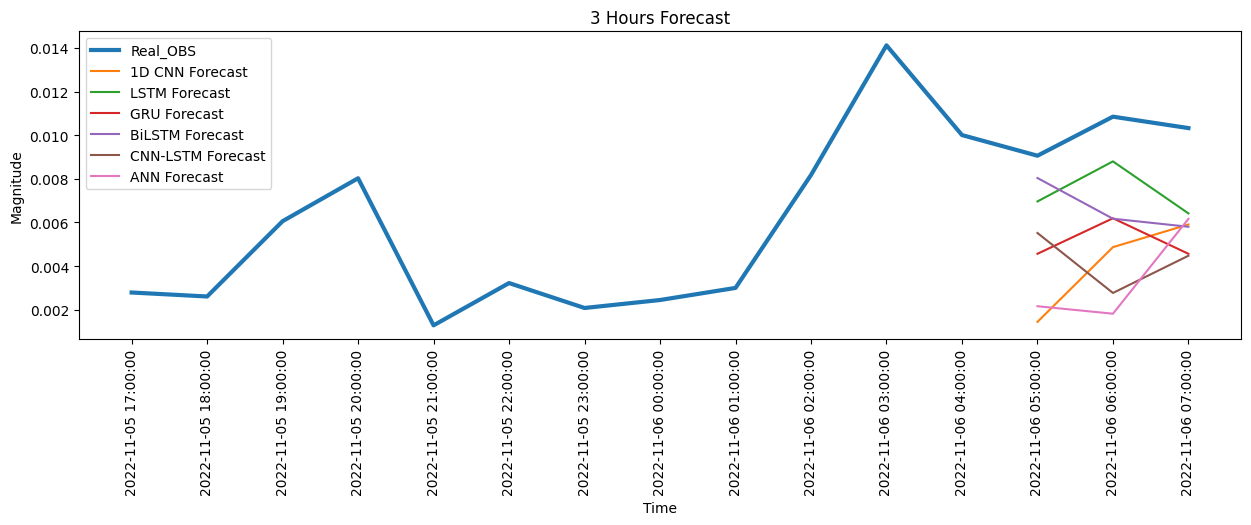

---- > Statistic of forecast for sensor 3_91355: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.006144  0.006004     0.871278 -65.852324             3
LSTM      0.002821  0.002684     0.556817 -13.090704             3
GRU       0.005002  0.004970     0.725506 -43.306128             3
BiLSTM    0.003802  0.003407    -0.903374 -24.602661             3
CNN-LSTM  0.006111  0.005823    -0.930813 -65.127193             3
ANN       0.006986  0.006696     0.163303 -85.436655             3
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.00

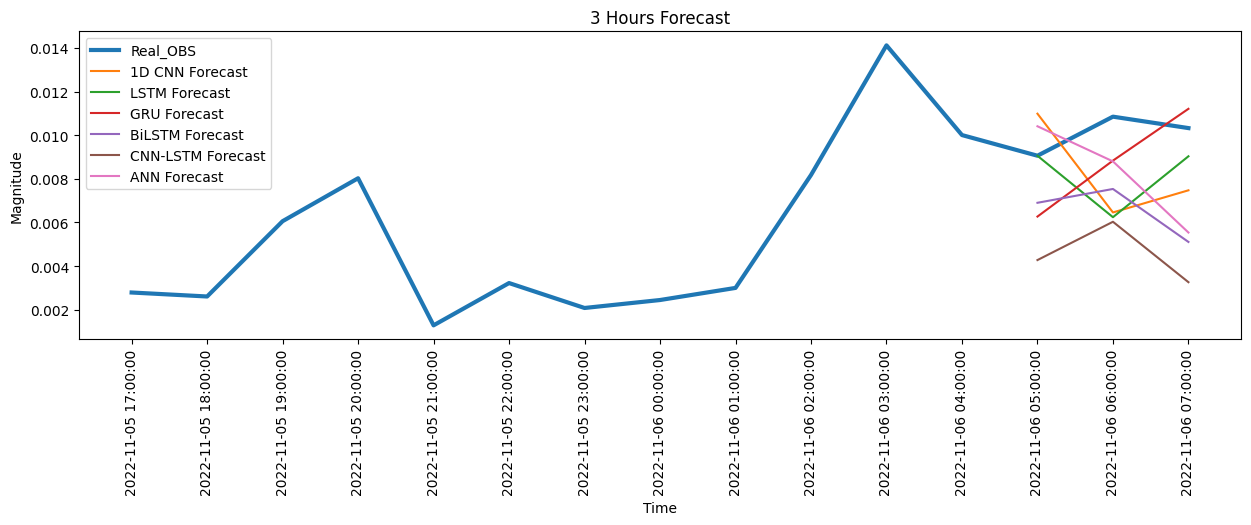

---- > Statistic of forecast for sensor 3_91721: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.003220  0.003056    -0.997317 -17.361680             3
LSTM      0.002762  0.001967    -0.730723 -12.513709             3
GRU       0.002050  0.001895     0.704065  -6.443349             3
BiLSTM    0.003779  0.003563     0.019132 -24.297521             3
CNN-LSTM  0.005655  0.005553     0.427538 -55.630051             3
ANN       0.003105  0.002729    -0.535754 -16.078259             3
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.00

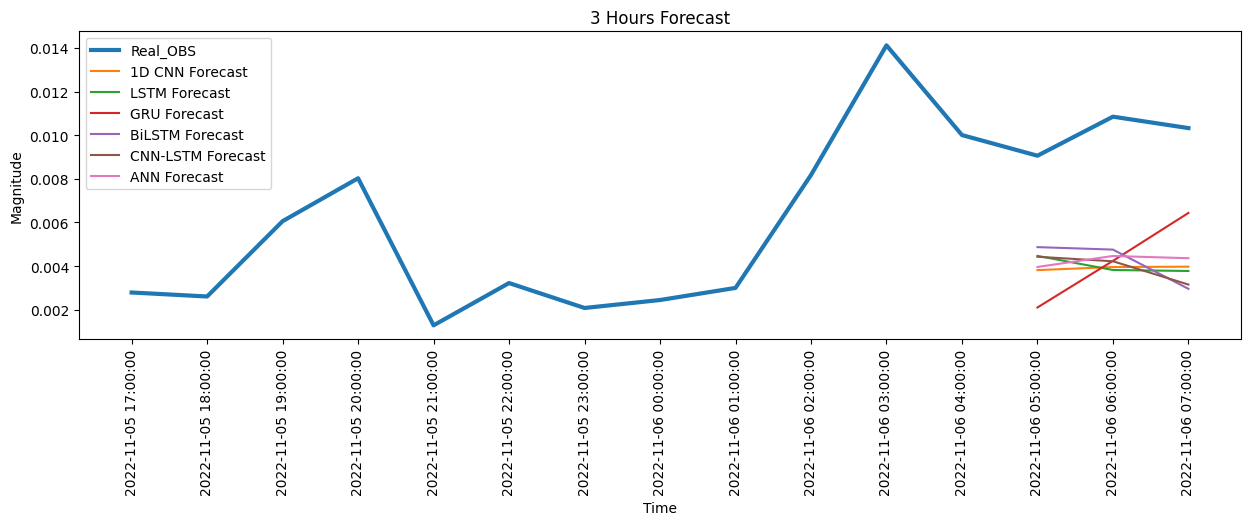

---- > Statistic of forecast for sensor 3_92367: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.006199  0.006161     0.926689 -67.059946             3
LSTM      0.006146  0.006055    -0.940520 -65.902180             3
GRU       0.005976  0.005816     0.682182 -62.244153             3
BiLSTM    0.006025  0.005882    -0.284050 -63.294881             3
CNN-LSTM  0.006239  0.006142    -0.377607 -67.926910             3
ANN       0.005840  0.005815     0.995480 -59.391683             3
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.00

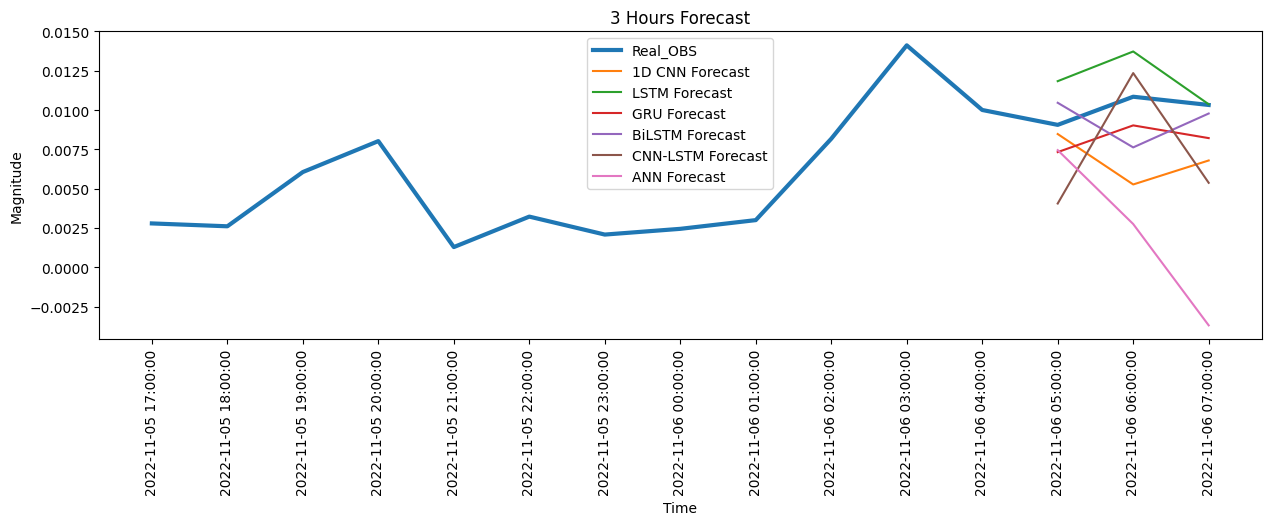

---- > Statistic of forecast for sensor 3_dsi: 
               RMSE       MAE  Pearson's r          R²  Pred. Length
Model                                                              
1D CNN    0.003827  0.003231    -0.978656  -24.942595             3
LSTM      0.002311  0.001901     0.352762   -8.455781             3
GRU       0.001894  0.001888     0.978563   -5.356085             3
BiLSTM    0.002054  0.001724    -0.864701   -6.470586             3
CNN-LSTM  0.004155  0.003819     0.819398  -29.580613             3
ANN       0.009392  0.007907    -0.619928 -155.227551             3
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00  

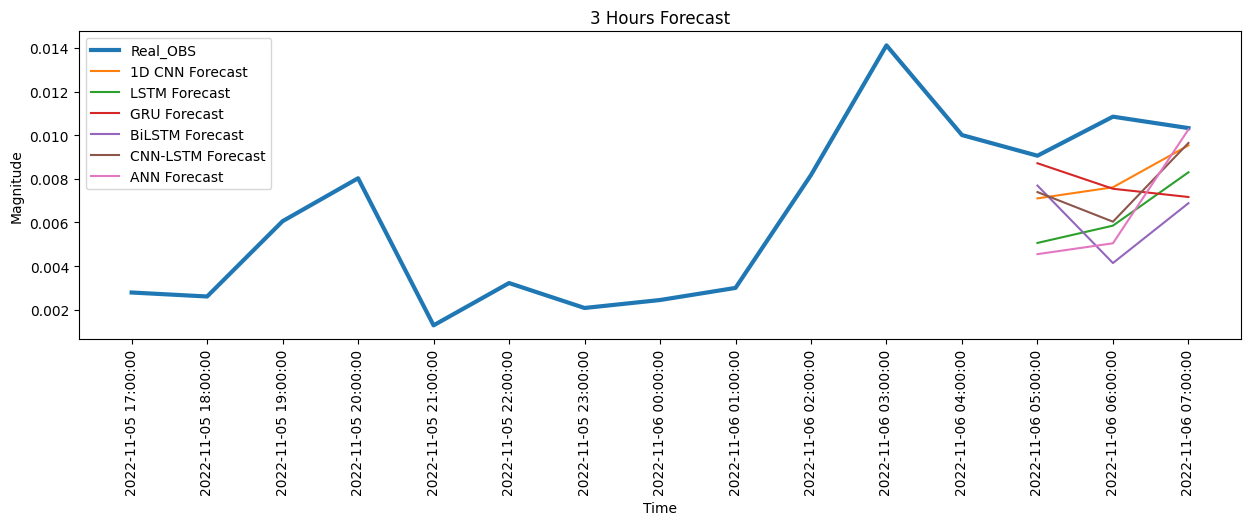

---- > Statistic of forecast for sensor 3_station: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.002231  0.001995     0.420988  -7.811522             3
LSTM      0.003874  0.003672     0.454563 -25.576887             3
GRU       0.002646  0.002269    -0.865320 -11.401071             3
BiLSTM    0.004424  0.003839    -0.857817 -33.659852             3
CNN-LSTM  0.002967  0.002387    -0.146036 -14.585194             3
ANN       0.004243  0.003458     0.308612 -30.886884             3
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.

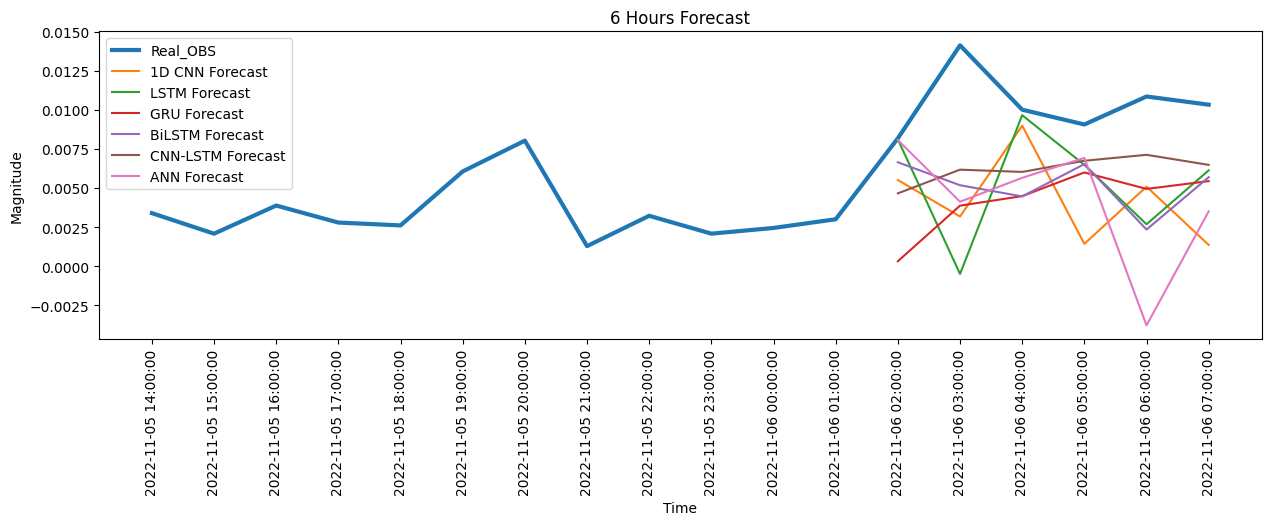

---- > Statistic of forecast for sensor 6_91355: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.007066  0.006164    -0.144209 -13.318555             6
LSTM      0.007126  0.004996    -0.849537 -13.560791             6
GRU       0.006651  0.006248     0.247863 -11.685107             6
BiLSTM    0.005962  0.005281    -0.373408  -9.191902             6
CNN-LSTM  0.004572  0.004223     0.351734  -4.993984             6
ANN       0.007999  0.006340    -0.386308 -17.346644             6
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.00

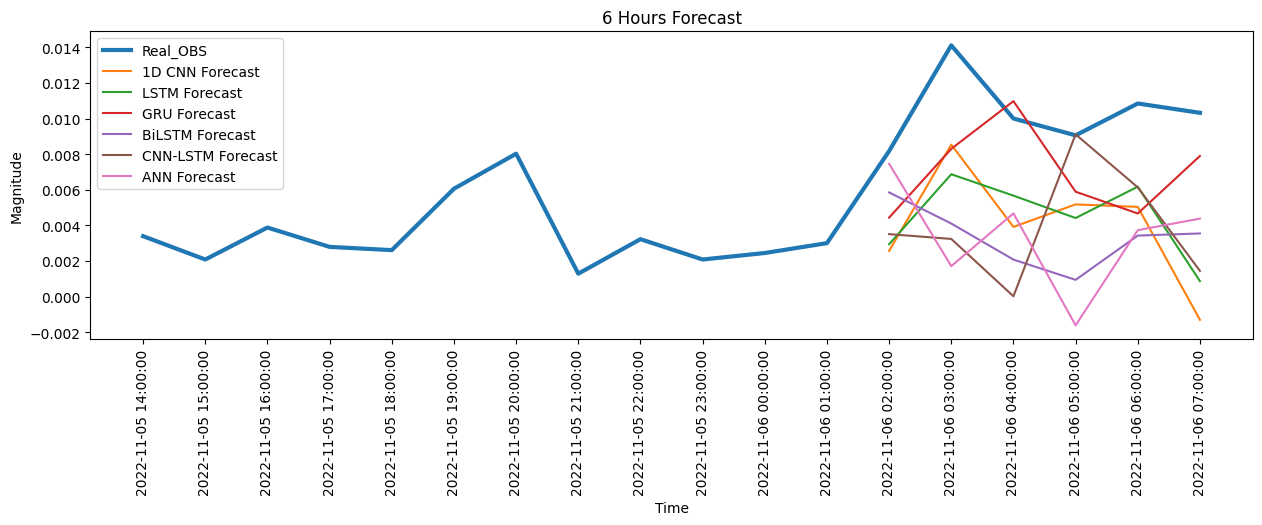

---- > Statistic of forecast for sensor 6_91721: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.006878  0.006434     0.580135 -12.566513             6
LSTM      0.006213  0.005933     0.562435 -10.068359             6
GRU       0.004141  0.003718     0.363296  -3.918395             6
BiLSTM    0.007479  0.007099     0.057629 -15.041108             6
CNN-LSTM  0.007540  0.006532    -0.174604 -15.302993             6
ANN       0.007989  0.007033    -0.286720 -17.303474             6
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.00

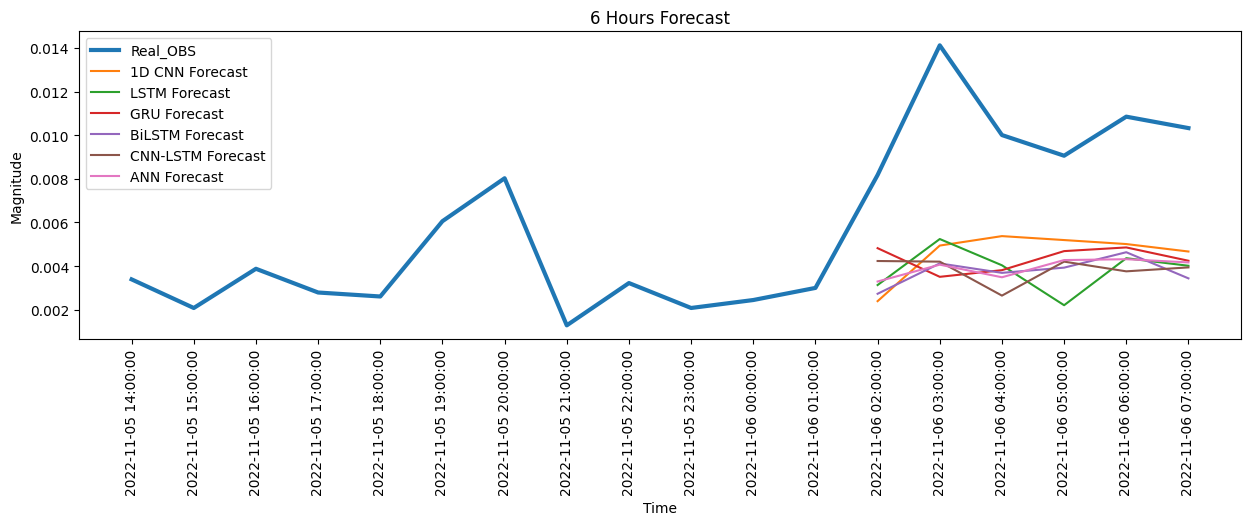

---- > Statistic of forecast for sensor 6_92367: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.006056  0.005824     0.464711  -9.517788             6
LSTM      0.006691  0.006589     0.851983 -11.839395             6
GRU       0.006508  0.006099    -0.723636 -11.143654             6
BiLSTM    0.006852  0.006663     0.582451 -12.463256             6
CNN-LSTM  0.006861  0.006589     0.066792 -12.500329             6
ANN       0.006718  0.006487     0.401372 -11.940031             6
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.00

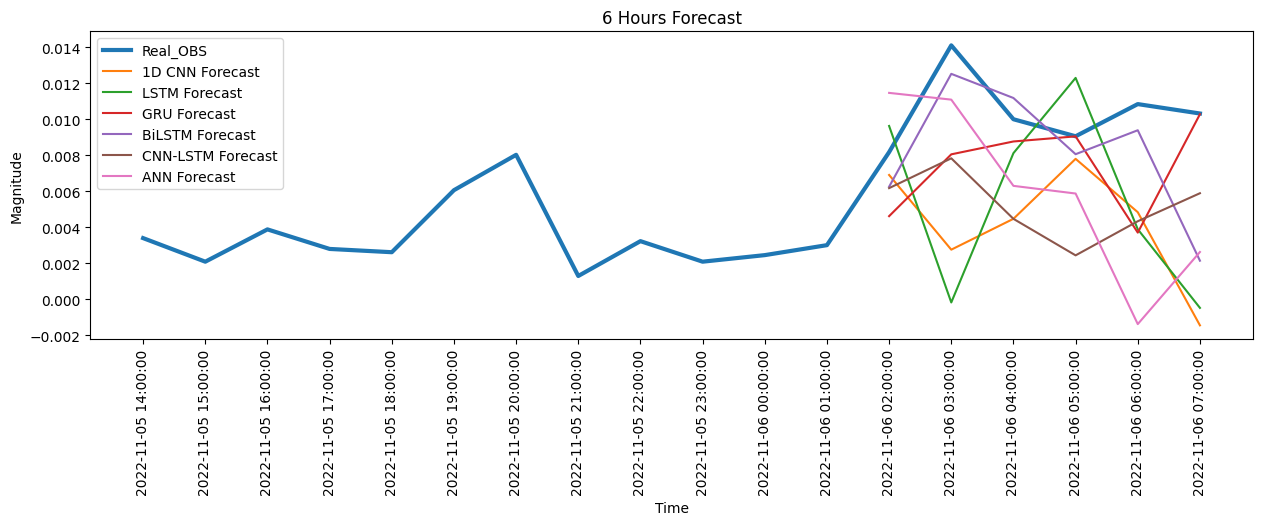

---- > Statistic of forecast for sensor 6_dsi: 
               RMSE       MAE  Pearson's r         R²  Pred. Length
Model                                                             
1D CNN    0.007508  0.006206    -0.461365 -15.162580             6
LSTM      0.008024  0.006445    -0.750522 -17.461309             6
GRU       0.004125  0.003009     0.147808  -3.880079             6
BiLSTM    0.003601  0.002556     0.534967  -2.718216             6
CNN-LSTM  0.005481  0.005235     0.587545  -7.615903             6
ANN       0.006495  0.005526     0.074425 -11.095037             6
--------------------------------------------------


datetime_utc
2022-11-05 01:00:00    0.005498
2022-11-05 02:00:00    0.004751
2022-11-05 03:00:00    0.006570
2022-11-05 04:00:00    0.006450
2022-11-05 05:00:00    0.004147
2022-11-05 06:00:00    0.005810
2022-11-05 07:00:00    0.006751
2022-11-05 08:00:00    0.007693
2022-11-05 09:00:00    0.007661
2022-11-05 10:00:00    0.005568
2022-11-05 11:00:00    0.0059

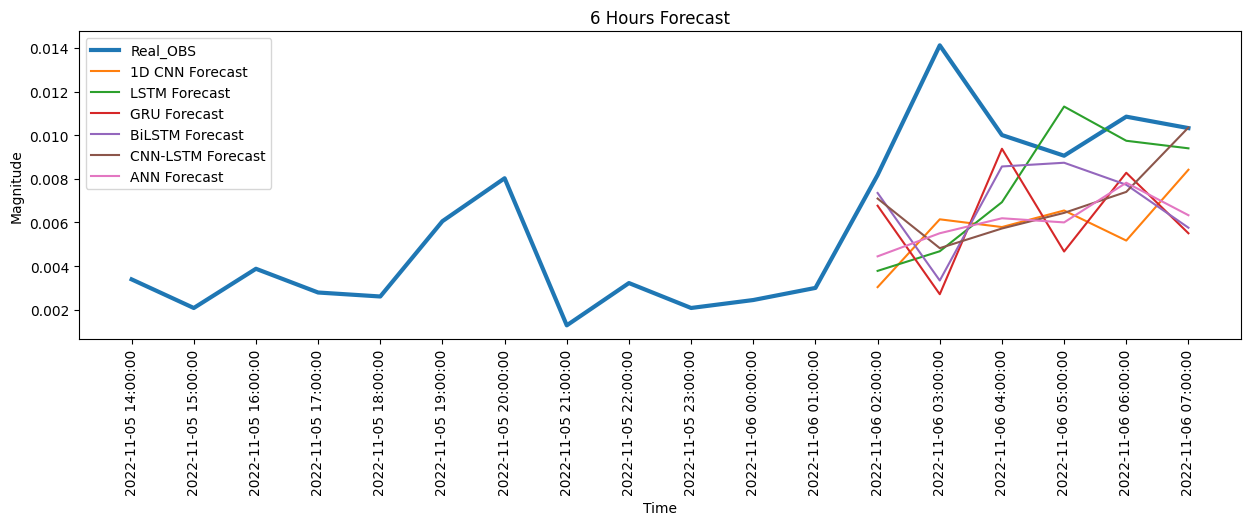

---- > Statistic of forecast for sensor 6_station: 
               RMSE       MAE  Pearson's r        R²  Pred. Length
Model                                                            
1D CNN    0.004999  0.004571     0.329478 -6.165323             6
LSTM      0.004564  0.003532    -0.203366 -4.972822             6
GRU       0.005501  0.004204    -0.499135 -7.678076             6
BiLSTM    0.004993  0.003508    -0.806060 -6.148559             6
CNN-LSTM  0.004558  0.003459    -0.365899 -4.956719             6
ANN       0.004779  0.004371     0.205595 -5.549111             6
--------------------------------------------------




In [ ]:
forecast_results =  {}
for forecast_length in pred_lengths:
  for i, key in enumerate(X_train.keys()):
    if((str(forecast_length)+'_') in key):    ### align length of forecast with segments of data
      ## Make forecast and plot
      forecast_results[key] = forecast(models[key], X_test[key], forecast_length)    ## Making prediction of last segement   [OK]
      ## Create plots   [Check]
      plot_forecasts(data_main['station'], forecast_results[key], forecast_length, f'{forecast_length} Hours Forecast')
      ## Forecast stats
      statistics = evaluate_forecasts(forecast_results[key], data_main['station'].iloc[-(forecast_length):])
      ## convert to dataframes
      df_stat = statistics_to_dataframe(statistics, forecast_length)
      print(f"---- > Statistic of forecast for sensor {key}: \n", df_stat)
      print('-'*50 )
      print('\n')

In [ ]:
# ---- > Statistic of forecast for sensor 6_91355:
#                RMSE       MAE  Pearson's r         R²  Pred. Length
# Model
# 1D CNN    0.005406  0.004750    -0.196939  -7.380240             6
# LSTM      0.005647  0.004760    -0.466956  -8.143579             6
# GRU       0.007504  0.006547    -0.451649 -15.146627             6
# BiLSTM    0.004160  0.003601    -0.617414  -3.963439             6
# CNN-LSTM  0.005102  0.004538     0.112328  -6.465234             6
# ANN       0.007538  0.006796     0.315925 -15.293370             6
# --------------------------------------------------


# ---- > Statistic of forecast for sensor 6_91721:
#                RMSE       MAE  Pearson's r         R²  Pred. Length
# Model
# 1D CNN    0.007761  0.007268     0.068198 -16.271254             6
# LSTM      0.005198  0.003429    -0.694689  -6.749354             6
# GRU       0.005208  0.004651     0.387225  -6.778148             6
# BiLSTM    0.008129  0.007365    -0.203245 -17.949626             6
# CNN-LSTM  0.006790  0.006027    -0.692468 -12.220591             6
# ANN       0.007025  0.006173     0.333742 -13.152934             6
# --------------------------------------------------


# ---- > Statistic of forecast for sensor 6_92367:
#                RMSE       MAE  Pearson's r         R²  Pred. Length
# Model
# 1D CNN    0.006161  0.005848     0.112145  -9.885590             6
# LSTM      0.006430  0.005885    -0.605748 -10.855625             6
# GRU       0.006839  0.006604     0.358343 -12.413937             6
# BiLSTM    0.007097  0.006537    -0.367587 -13.444266             6
# CNN-LSTM  0.007059  0.006617    -0.628257 -13.287277             6
# ANN       0.007298  0.007034     0.015756 -14.273698             6
# --------------------------------------------------


# ---- > Statistic of forecast for sensor 6_dsi:
#                RMSE       MAE  Pearson's r         R²  Pred. Length
# Model
# 1D CNN    0.003488  0.002725    -0.364914  -2.488040             6
# LSTM      0.005148  0.004829    -0.166022  -6.599865             6
# GRU       0.007120  0.005354    -0.754527 -13.535055             6
# BiLSTM    0.006841  0.005251    -0.300075 -12.418021             6
# CNN-LSTM  0.005898  0.005449    -0.156910  -8.975563             6
# ANN       0.009009  0.007910     0.289157 -22.274731             6
# --------------------------------------------------


# ---- > Statistic of forecast for sensor 6_station:
#                RMSE       MAE  Pearson's r        R²  Pred. Length
# Model
# 1D CNN    0.005193  0.004331    -0.166653 -6.734255             6
# LSTM      0.004683  0.003550    -0.329062 -5.288553             6
# GRU       0.004524  0.003989     0.231740 -4.868712             6
# BiLSTM    0.005872  0.004736    -0.442800 -8.885872             6
# CNN-LSTM  0.005247  0.004411    -0.135473 -6.895221             6
# ANN       0.004612  0.004144     0.137691 -5.100154             6
# --------------------------------------------------

In [ ]:
# !git add .
# !git commit -m "nowcasting fig"
# !git push https://github.com/Hoang-Trung-Le/nowcasting_framework.git

In [ ]:
a = np.array([[0.00364314, 0.00495138, 0.00567521]])
a.reshape(3,1)

array([[0.00364314],
       [0.00495138],
       [0.00567521]])

In [ ]:
import pandas as pd

# Example statistics data for individual sensors and DSI
sensor_stats = {
    "6_91355": {
        "1D CNN": {"RMSE": 0.005406, "MAE": 0.004750, "Pearson's r": -0.196939, "R²": -7.380240, "Pred. Length": 6},
        "LSTM": {"RMSE": 0.005647, "MAE": 0.004760, "Pearson's r": -0.466956, "R²": -8.143579, "Pred. Length": 6},
        "GRU": {"RMSE": 0.007504, "MAE": 0.006547, "Pearson's r": -0.451649, "R²": -15.146627, "Pred. Length": 6},
        "BiLSTM": {"RMSE": 0.004160, "MAE": 0.003601, "Pearson's r": -0.617414, "R²": -3.963439, "Pred. Length": 6},
        "CNN-LSTM": {"RMSE": 0.005102, "MAE": 0.004538, "Pearson's r": 0.112328, "R²": -6.465234, "Pred. Length": 6},
        "ANN": {"RMSE": 0.007538, "MAE": 0.006796, "Pearson's r": 0.315925, "R²": -15.293370, "Pred. Length": 6}
    },
    "6_91721": {
        "1D CNN": {"RMSE": 0.007761, "MAE": 0.007268, "Pearson's r": 0.068198, "R²": -16.271254, "Pred. Length": 6},
        "LSTM": {"RMSE": 0.005198, "MAE": 0.003429, "Pearson's r": -0.694689, "R²": -6.749354, "Pred. Length": 6},
        "GRU": {"RMSE": 0.005208, "MAE": 0.004651, "Pearson's r": 0.387225, "R²": -6.778148, "Pred. Length": 6},
        "BiLSTM": {"RMSE": 0.008129, "MAE": 0.007365, "Pearson's r": -0.203245, "R²": -17.949626, "Pred. Length": 6},
        "CNN-LSTM": {"RMSE": 0.006790, "MAE": 0.006027, "Pearson's r": -0.692468, "R²": -12.220591, "Pred. Length": 6},
        "ANN": {"RMSE": 0.007025, "MAE": 0.006173, "Pearson's r": 0.333742, "R²": -13.152934, "Pred. Length": 6}
    },
    "6_92367": {
        "1D CNN": {"RMSE": 0.006161, "MAE": 0.005848, "Pearson's r": 0.112145, "R²": -9.885590, "Pred. Length": 6},
        "LSTM": {"RMSE": 0.006430, "MAE": 0.005885, "Pearson's r": -0.605748, "R²": -10.855625, "Pred. Length": 6},
        "GRU": {"RMSE": 0.006839, "MAE": 0.006604, "Pearson's r": 0.358343, "R²": -12.413937, "Pred. Length": 6},
        "BiLSTM": {"RMSE": 0.007097, "MAE": 0.006537, "Pearson's r": -0.367587, "R²": -13.444266, "Pred. Length": 6},
        "CNN-LSTM": {"RMSE": 0.007059, "MAE": 0.006617, "Pearson's r": -0.628257, "R²": -13.287277, "Pred. Length": 6},
        "ANN": {"RMSE": 0.007298, "MAE": 0.007034, "Pearson's r": 0.015756, "R²": -14.273698, "Pred. Length": 6}
    }
}

dsi_stats = {
    "1D CNN": {"RMSE": 0.003488, "MAE": 0.002725, "Pearson's r": -0.364914, "R²": -2.488040, "Pred. Length": 6},
    "LSTM": {"RMSE": 0.005148, "MAE": 0.004829, "Pearson's r": -0.166022, "R²": -6.599865, "Pred. Length": 6},
    "GRU": {"RMSE": 0.007120, "MAE": 0.005354, "Pearson's r": -0.754527, "R²": -13.535055, "Pred. Length": 6},
    "BiLSTM": {"RMSE": 0.006841, "MAE": 0.005251, "Pearson's r": -0.300075, "R²": -12.418021, "Pred. Length": 6},
    "CNN-LSTM": {"RMSE": 0.005898, "MAE": 0.005449, "Pearson's r": -0.156910, "R²": -8.975563, "Pred. Length": 6},
    "ANN": {"RMSE": 0.009009, "MAE": 0.007910, "Pearson's r": 0.289157, "R²": -22.274731, "Pred. Length": 6}
}

# Function to calculate the average statistics for individual sensors
def average_sensor_stats(sensor_stats):
    avg_stats = {}
    for model in sensor_stats[list(sensor_stats.keys())[0]].keys():
        avg_stats[model] = {
            "RMSE": sum(sensor_stats[sensor][model]["RMSE"] for sensor in sensor_stats) / len(sensor_stats),
            "MAE": sum(sensor_stats[sensor][model]["MAE"] for sensor in sensor_stats) / len(sensor_stats),
            "Pearson's r": sum(sensor_stats[sensor][model]["Pearson's r"] for sensor in sensor_stats) / len(sensor_stats),
            "R²": sum(sensor_stats[sensor][model]["R²"] for sensor in sensor_stats) / len(sensor_stats),
        }
    return avg_stats

# Calculate the average statistics for the sensors
avg_sensor_stats = average_sensor_stats(sensor_stats)

# Function to calculate improvement
def calculate_improvement(dsi_stats, avg_sensor_stats):
    improvement = {}
    for model in dsi_stats.keys():
        improvement[model] = {
            "RMSE Improvement (%)": ((avg_sensor_stats[model]["RMSE"] - dsi_stats[model]["RMSE"]) / avg_sensor_stats[model]["RMSE"]) * 100,
            "MAE Improvement (%)": ((avg_sensor_stats[model]["MAE"] - dsi_stats[model]["MAE"]) / avg_sensor_stats[model]["MAE"]) * 100,
            "Pearson's r Improvement": (dsi_stats[model]["Pearson's r"] - avg_sensor_stats[model]["Pearson's r"]),
            "R² Improvement": (dsi_stats[model]["R²"] - avg_sensor_stats[model]["R²"]),
        }
    return improvement

# Calculate the improvement of DSI compared to the average sensor statistics
improvement = calculate_improvement(dsi_stats, avg_sensor_stats)

# Display the improvement
improvement_df = pd.DataFrame(improvement).T
print(improvement_df)


          RMSE Improvement (%)  MAE Improvement (%)  Pearson's r Improvement  \
1D CNN               45.860927            54.242696                -0.359382   
LSTM                 10.599132            -2.934489                 0.423109   
GRU                  -9.252724             9.774183                -0.852500   
BiLSTM               -5.865057             9.998286                 0.096007   
CNN-LSTM              6.632895             4.859737                 0.245889   
ANN                 -23.631124           -18.632205                 0.067349   

          R² Improvement  
1D CNN          8.690988  
LSTM            1.982988  
GRU            -2.088818  
BiLSTM         -0.632244  
CNN-LSTM        1.682138  
ANN            -8.034730  
